# SpatialData interoperability


Currently, interoperability with `SpatialData` is limited, though it is possible to convert SpatialData images to the required format for `spatiomic` analyses, as exemplified in this tutorial. As the standard matures, we will strive to add better SpatialData support in the future.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import spatialdata as sd

import spatiomic as so

/Users/au734063/Documents/spatiomic/.venv/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/au734063/Documents/spatiomic/.venv/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


Load an example CycIF image SpatialData object.


In [2]:
data_link = "https://s3.embl.de/spatialdata/spatialdata-sandbox/mcmicro_io.zarr/"
sdata = sd.read_zarr(data_link)
sdata.images

/Users/au734063/Documents/spatiomic/.venv/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/Users/au734063/Documents/spatiomic/.venv/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


{'exemplar-001_image': <xarray.DataArray 'image' (c: 12, y: 3139, x: 2511)> Size: 189MB
dask.array<from-zarr, shape=(12, 3139, 2511), dtype=uint16, chunksize=(1, 3139, 2511), chunktype=numpy.ndarray>
Coordinates:
  * c        (c) <U5 240B 'DNA_6' 'ELANE' 'CD57' ... 'ECAD' 'FOXP3' 'NCAM'
  * y        (y) float64 25kB 0.5 1.5 2.5 3.5 ... 3.136e+03 3.138e+03 3.138e+03
  * x        (x) float64 20kB 0.5 1.5 2.5 3.5 ... 2.508e+03 2.51e+03 2.51e+03
Attributes:
    transform:  {'global': Identity }}

Convert it to a NumPy array and get the channel names.


In [3]:
data, channel_names = so.data.array_from_sdata(sdata, image_name=next(iter(sdata.images.keys())))
data.shape, channel_names

((2511, 3139, 12),
 ['DNA_6',
  'ELANE',
  'CD57',
  'CD45',
  'DNA_7',
  'CD11B',
  'SMA',
  'CD16',
  'DNA_8',
  'ECAD',
  'FOXP3',
  'NCAM'])

## Pixel-level clustering using the data


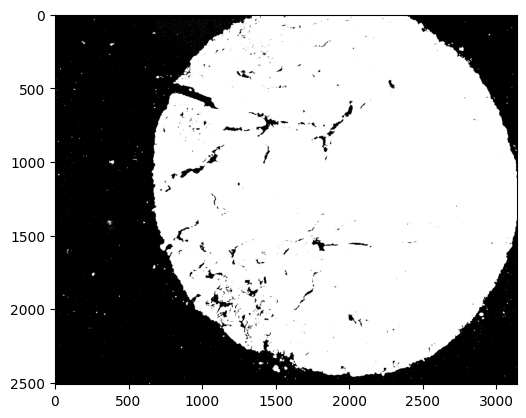

In [4]:
max_projection = data.max(axis=-1)
binary_mask = max_projection > 1000
pixels_foreground = data[binary_mask]
plt.imshow(binary_mask, cmap="gray")

In [5]:
clipper = so.process.clip(percentile_min=1, percentile_max=99.9)
normalizer = so.process.normalize()

In [6]:
pixels_foreground_clipped = clipper.fit_transform(pixels_foreground)
pixels_foreground_normalized = normalizer.fit_transform(pixels_foreground_clipped)

/Users/au734063/Documents/spatiomic/spatiomic/_internal/_anndata_method.py:216: UserWarning: Data does not appear to be a numpy/cupy float, casting to numpy float32.
  result = method(*method_args, *processed_args, **kwargs)
/Users/au734063/Documents/spatiomic/spatiomic/process/_clip.py:105: UserWarning: Data has only two dimensions. Assuming flat data with one channel dimension. This will yield unwanted results when called on 2D images without channel dimension.
  check_channel_dimension(data.shape)
/Users/au734063/Documents/spatiomic/spatiomic/process/_normalize.py:69: UserWarning: Data has only two dimensions. Assuming flat data with one channel dimension. This will yield unwanted results when called on 2D images without channel dimension.
  check_channel_dimension(data.shape)


In [7]:
subsample = so.data.subsample().fit_transform(pixels_foreground_normalized, method="count", count=100000, seed=0)
som = so.dimension.som(
    node_count=(20, 20),
    dimension_count=subsample.shape[1],
    seed=0,
)
som.fit(subsample, iteration_count=20)

/Users/au734063/Documents/spatiomic/spatiomic/dimension/_som.py:126: UserWarning: Could not import cuml implementation. Switching to non-GPU implementation.
  self.neighbor_estimator = get_neighbor_finder(


In [8]:
knn_graph = so.neighbor.knn_graph().create(som, neighbor_count=10)
communities, modularity = so.cluster.leiden().predict(knn_graph, resolution=0.8)

/Users/au734063/Documents/spatiomic/spatiomic/neighbor/_knn_graph.py:66: UserWarning: Could not import cuml implementation. Switching to non-GPU implementation.
  neighbor_finder = get_neighbor_finder(


In [9]:
communities = np.array(communities) + 1
background_image = np.zeros_like(max_projection)
background_image[binary_mask] = som.label(pixels_foreground_normalized, communities)

/var/folders/vg/vt1jjh256dn1g4sd6pknwxbs_qmnws/T/ipykernel_33547/4274450172.py:3: UserWarning: The glasbey color palette is part of colorcet and distributed under the Creative Commons Attribution 4.0 International Public License (CC-BY).
  colormap=so.plot.colormap(


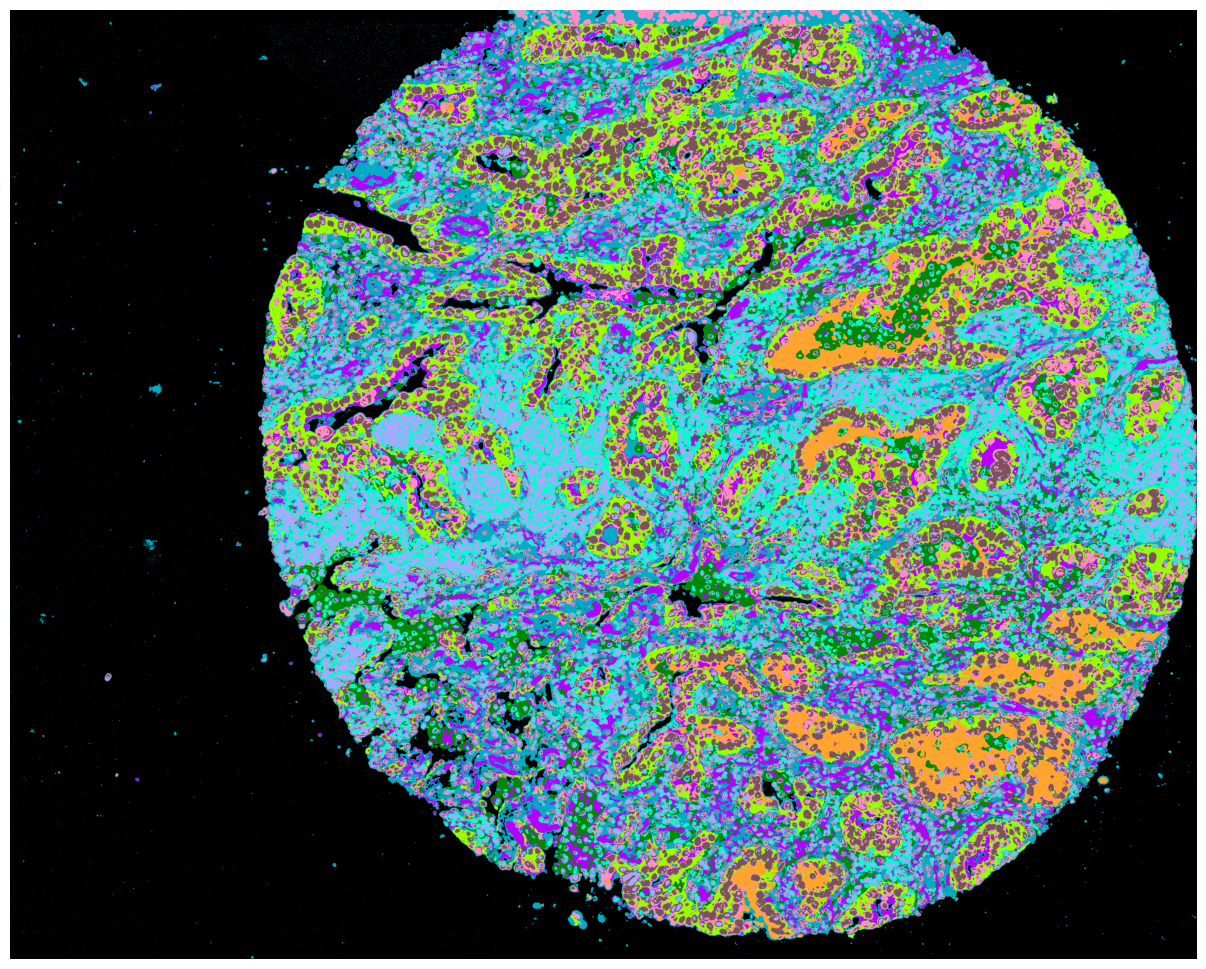

In [10]:
fig = so.plot.cluster_image(
    background_image,
    colormap=so.plot.colormap(
        color_count=len(np.unique(communities)) + 1,
        flavor="glasbey",
        color_override={0: "#000000"},
    ),
    figsize=(12, 12),
    show_colorbar=False,
)